In [101]:
#Aufgabe 1.1.

import numpy as np
import pandas as pd

listings = pd.read_csv("Daten/listings_berlin.csv")

print(f"Anzahl Zeilen: {len(listings)} \nAnzahl Spalten: {len(listings.columns)}")

Anzahl_NAs = listings.isna().sum()
Anteil_NAs = listings.isna().mean().map("{:.2%}".format)

Table_1_1 = pd.DataFrame({"Anzahl NAs":Anzahl_NAs, "Anteil NAs":Anteil_NAs})
Table_1_1.head(20)

Anzahl Zeilen: 14274 
Anzahl Spalten: 20


,Anzahl NAs,Anteil NAs
price,5010,35.10%
neighbourhood_cleansed,0,0.00%
latitude,0,0.00%
longitude,0,0.00%
room_type,0,0.00%
bedrooms,2024,14.18%
bathrooms_text,16,0.11%
accommodates,0,0.00%
amenities,0,0.00%
host_since,14,0.10%


In [102]:
#Aufagbe 1.2
#Die Tabelle aus Aufgabe 1_1 wird nach den Werten in Spalte "Anteil NAs" in "descending"-order sortiert. 
#Es werden nur die obersten drei Werte angezeigt. 
print("Die folgenden drei Werte haben die höchste Rate an fehlenden Werten:")
Table_1_1.sort_values("Anteil NAs", ascending=False).head(3)


Die folgenden drei Werte haben die höchste Rate an fehlenden Werten:


,Anzahl NAs,Anteil NAs
host_response_rate,5018,35.15%
price,5010,35.10%
reviews_per_month,3314,23.22%


placeholder für den Rest von Aufgabe 1_2

In [78]:
#Aufgabe 1_3
#Funktion wird definiert, um string-Einträge in numbers-Einträge umzuwandeln.
def clean_price(price_str):
    """Diese Funktion wandelt string in numeric um."""

    if pd.isna(price_str):
        return np.nan
    price_str_clean = str(price_str).replace("$", "").replace(',', '')
    try:
        price_number = float(price_str_clean)
        if price_number > 0:
            return price_number
        else:
            return np.nan
    except ValueError:
        return np.nan
#Nun wenden wir es auf die gesamte Spalte "price" an.
listings_1_3 = listings.copy()
listings_1_3["price"] = listings_1_3["price"].apply(clean_price)
listings_1_3["price"].describe().loc[['min', '50%', 'mean', 'max']]

min         5.000000
50%       104.000000
mean      201.240393
max     50000.000000
Name: price, dtype: float64

In [79]:
#Aufgabe 1.4
listings_1_4 = listings_1_3.copy()
#Zunächst schauen wir, welche einzigartigen Einträge es gibt mit:
#listings_1_4["bathrooms_text"].unique()

#Wir wollen nun die Textdarstellung der Bädersituationen umwandeln in eine numerische Form.
#Regel 1: Die Spezifikation eines "Privaten" Bades ist redundant.
#Regel 2: Die Information eines "Shared" Bades wird durch eine neue boolean-Spalte "Shared_bath_status" erhalten.
#Regel 3: Ein "Half"-Bad gilt als 0.5 Bad.

#Umsetzung Regel 2:
listings_1_4["Shared_bath_status"] = listings_1_4["bathrooms_text"].str.contains("shared", case=False)
#Umsetzung Regel 3:
listings_1_4["bathrooms_text"] = listings_1_4["bathrooms_text"].str.replace("Half-Bath", "0.5", case=False)
#Umsetzung der Umwandlung zu Numerisch unter Beachtung der Regel 1:
listings_1_4["bathrooms_text"] = pd.to_numeric(
    listings_1_4["bathrooms_text"].str.replace({
    "baths": "",
    "shared": "",
    "private": "",
    "bath": "",
    " ": ""
    }, case=False)
)
listings_1_4[["bathrooms_text", "Shared_bath_status"]].head()

,bathrooms_text,Shared_bath_status
0,1.0,False
1,2.5,False
2,1.0,False
3,1.0,False
4,1.0,False


In [80]:
#Aufgabe 1.5
listings_1_5 = listings_1_4.copy()
#Zunächst konvertieren wir "t" zu True und "f" zu False, und NaN auch zu False, da der Standard False ist.
listings_1_5["instant_bookable"] = listings_1_5["instant_bookable"] == "t"
listings_1_5["host_is_superhost"] = listings_1_5["host_is_superhost"] == "t"
#Wir kreieren die Spalte "host_tenure_years" und verwerfen die Spalte "host_since", da die Informationen redundant werden.
#Datenformat ist egal, da nur das Jahr abgefragt wird.
listings_1_5["host_tenure_years"] = 2025 - pd.to_datetime(listings_1_5["host_since"]).dt.year
#Wir droppen die Spalte "host_since".
listings_1_5 = listings_1_5.drop(columns="host_since")
listings_1_5.columns

Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_text', 'accommodates', 'amenities',
       'host_is_superhost', 'host_listings_count', 'host_response_rate',
       'review_scores_rating', 'review_scores_cleanliness',
       'number_of_reviews', 'reviews_per_month', 'minimum_nights',
       'availability_365', 'instant_bookable', 'Shared_bath_status',
       'host_tenure_years'],
      dtype='str')

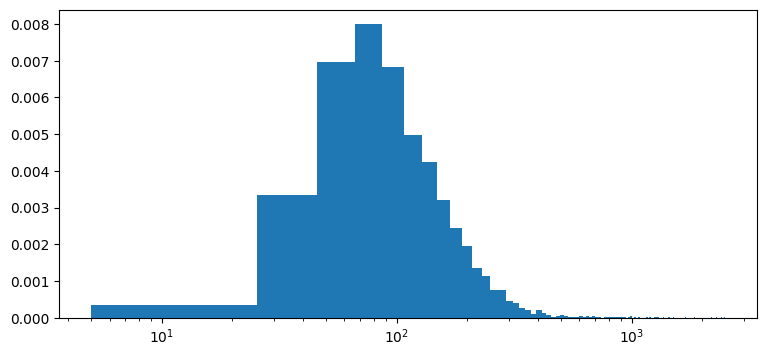

3214.253030361427


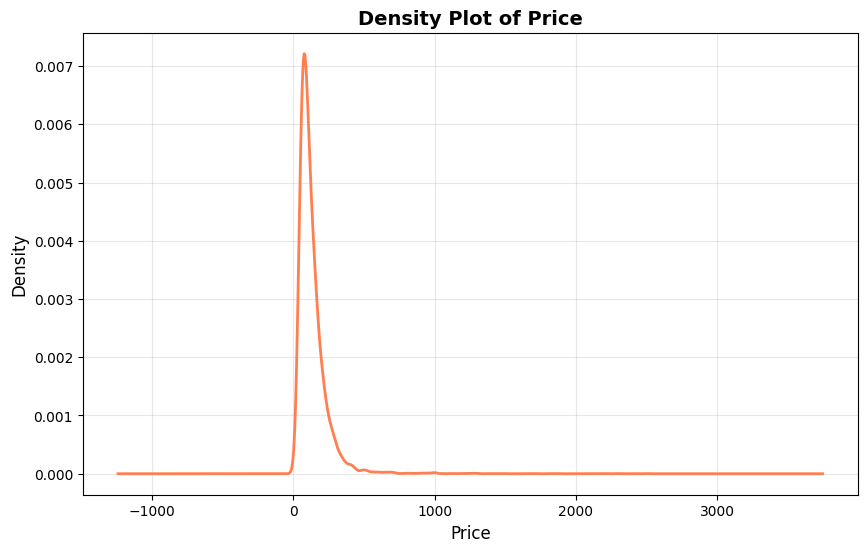

In [86]:
#Aufgabe 1.6
import matplotlib.pyplot as plt


log_prices = np.log(listings_1_5["price"])

mu_log = np.mean(log_prices)
sigma_log = np.std(log_prices)

upper_bound = np.exp(mu_log + 5 * sigma_log)
fig = plt.figure(figsize=(9, 4))
plt.hist(
    listings_1_5.loc[listings_1_5["price"] <= upper_bound]["price"],
    log= False, bins = 122,
    density=True,
    label='empirical density'
) # plotting a histogram 
plt.xscale("log")
plt.show()
print(upper_bound)
#Muss noch mit linearer x-Achse dargestellt werden

plt.figure(figsize=(10, 6))

listings_1_5.loc[listings_1_5["price"] <= upper_bound]["price"].dropna().plot(
    kind="density",
    color="coral",
    linewidth=2
)

plt.xlabel("Price", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Density Plot of Price", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
#plt.xscale("log")

plt.show()
#Noch nicht fertig durchdacht

In [82]:
#Unterbrechung in x-Achse machen

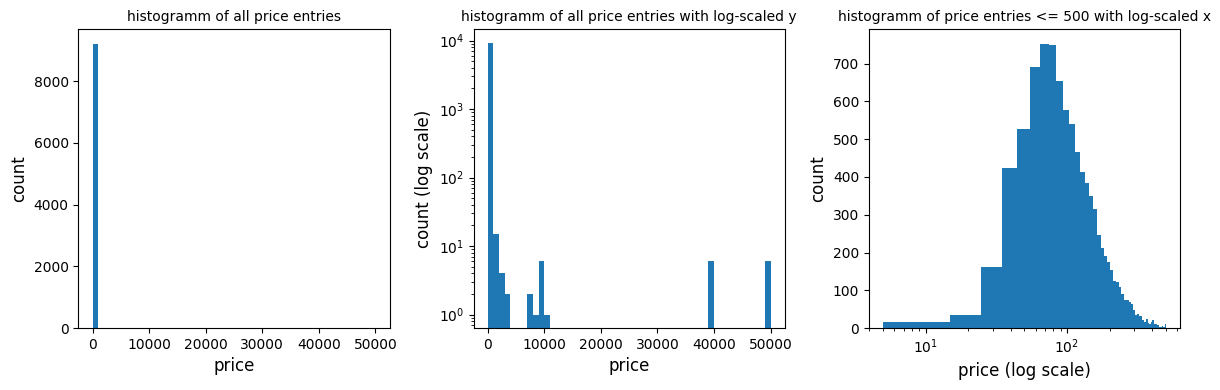

In [178]:
# Aufgabe 1.6 "preperation" Jan
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].hist(listings_1_5["price"], bins=50)
ax[0].set_xlabel("price", fontsize=12)
ax[0].set_ylabel("count", fontsize=12)
ax[0].set_title("histogramm of all price entries", fontsize=10)

ax[1].hist(listings_1_5["price"], bins=50, log=True)
ax[1].set_xlabel("price", fontsize=12)
ax[1].set_ylabel("count (log scale)", fontsize=12)
ax[1].set_title("histogramm of all price entries with log-scaled y", fontsize=10)

ax[2].hist(listings_1_5.loc[listings_1_5["price"] <= 500]["price"], bins=50, log=False)
ax[2].set_xscale("log")
ax[2].set_xlabel("price (log scale)", fontsize=12)
ax[2].set_ylabel("count", fontsize=12)
ax[2].set_title("histogramm of price entries <= 500 with log-scaled x", fontsize=10)

plt.tight_layout()
plt.show()

Erkenntnis: Outlier verzerren das Hist; Outlier (etwa) bei 10000, 40000, und 50000; Preise sind (etwa) log-normalverteilt

Upper Bound at sigma level 5: 3214.25     Upper Bound at sigma level 3: 828.76
Number of entries at 5-sigma UB: 9240     Number of entries with 3-sigma UB: 9202


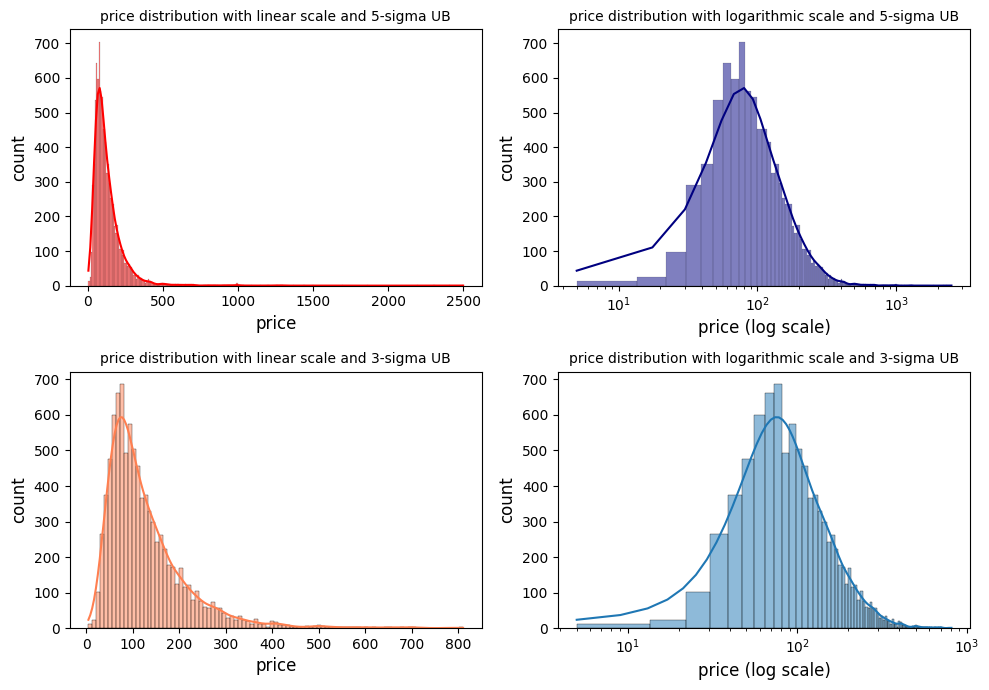

In [179]:
# Aufgabe 1.6 "main" Jan
# Variante mit Seaborn und zwei Upper Bounds

import seaborn as sns

log_prices = np.log(listings_1_5["price"])
mu_log = np.mean(log_prices)
sigma_log = np.std(log_prices)

upper_bound = np.exp(mu_log + 5 * sigma_log)
upper_bound_low = np.exp(mu_log + 3 * sigma_log)

n_entries_ub = (listings_1_5["price"] <= upper_bound).sum()
n_entries_ub_low = (listings_1_5["price"] <= upper_bound_low).sum()

print(f"Upper Bound at sigma level 5: {upper_bound:.2f}     Upper Bound at sigma level 3: {upper_bound_low:.2f}")
print(f"Number of entries at 5-sigma UB: {n_entries_ub }     Number of entries with 3-sigma UB: {n_entries_ub_low}")


fig, ax = plt.subplots( 2, 2, sharey=False, figsize=(10,7) )

sns.histplot( data=listings_1_5.loc[listings_1_5["price"] <= upper_bound], x="price", kde=True, ax=ax[0,0], log=False,  bins="fd", color="red", stat="count")
ax[0,0].set_xlabel("price", fontsize=12)
ax[0,0].set_ylabel("count", fontsize=12)
ax[0,0].set_title("price distribution with linear scale and 5-sigma UB", fontsize=10)

sns.histplot( data=listings_1_5.loc[listings_1_5["price"] <= upper_bound], x="price", kde=True, ax=ax[0,1], log=False,  bins="fd", color="navy", stat="count") 
ax[0,1].set_xlabel("price (log scale)", fontsize=12)
ax[0,1].set_ylabel("count", fontsize=12)
ax[0,1].set_xscale("log")
ax[0,1].set_title("price distribution with logarithmic scale and 5-sigma UB", fontsize=10)

sns.histplot( data=listings_1_5.loc[listings_1_5["price"] <= upper_bound_low], x="price", kde=True, ax=ax[1,0], log=False,  bins="fd", color="coral", stat="count")
ax[1,0].set_xlabel("price", fontsize=12)
ax[1,0].set_ylabel("count", fontsize=12)
ax[1,0].set_title("price distribution with linear scale and 3-sigma UB", fontsize=10)

sns.histplot( data=listings_1_5.loc[listings_1_5["price"] <= upper_bound_low], x="price", kde=True, ax=ax[1,1], log=False,  bins="fd", stat="count") 
ax[1,1].set_xlabel("price (log scale)", fontsize=12)
ax[1,1].set_ylabel("count", fontsize=12)
ax[1,1].set_xscale("log")
ax[1,1].set_title("price distribution with logarithmic scale and 3-sigma UB", fontsize=10)

plt.tight_layout()
plt.show()

Erklärung: 5-Sigma UB ist statistisch schränkt nur wenig ein => erhält möglichst viele Infos. 3-Sigma UB ist bewusst etwas einschränkender zur Übersichtlichkeit.

Vielleicht wären absolute Häufigkeiten doch besser! (Ich habe jetzt absolute genommen)

Die Bins wurden gemäß der Freedman-Diaconis Regel (die gibt es als bins="fd" vordefiniert) berechnet.

Welche Variante eignet sich bessert für statistische Analyse?
Idee?
log-normalverteilte Daten, typisch für Immoblilien  (Quelle?)

WICHTIG: NOCHMAL CHECKEN, OB DIESE UPPER BOUND-FORMELN SINN MACHEN!!!!!

In [198]:
# Aufgabe 1.7
listings_1_7 = listings_1_5.copy()

# group the data by "neighbourhood_cleansed" and calculate the mean, median, count for "price" and mean for "review_scores_rating"

table_1_7 =listings_1_7.groupby("neighbourhood_cleansed").agg({"price": ["mean", "median", "count"], "review_scores_rating": "mean"})

# round the mean values to 2 decimal places and sort the table by the median price in descending order
table_1_7 = table_1_7.round({("price","mean"): 2, ("review_scores_rating", "mean"): 2}).sort_values(("price", "median"), ascending=False)

table_1_7.head(3)

# The three most expensive are Haselhorst, West 5, and Schmargendorf.

price              review_scores_rating
                          mean median count                 mean
neighbourhood_cleansed                                          
Haselhorst              216.17  236.5     6                 4.86
West 5                  381.55  203.0    11                 4.79
Schmargendorf           170.56  172.0    34                 4.66

In [ ]:
# Aufgabe 1.8 

def trimmed_mean(x, pct):
    """This function calculates the trimmed mean of a given array x, removing the lowest and highest pct-points of values."""
    if not (isinstance(pct, (int, float)) and 0 <= pct < 50): 
        raise ValueError("pct must be a number between 0 and 50")
    try:
        x = np.asarray(x, dtype=float)
    except (TypeError, ValueError):
        raise TypeError("x must be an array-like object containing numeric values")
    if x.ndim != 1:
        raise ValueError("x must be one-dimensional")
    bound = int(len(x) * pct / 100)
    if bound == 0:
        return np.mean(x)
    if 2*bound >= len(x):
        raise ValueError("pct too large for the size of x")
    x = x[~np.isnan(x)]
    x = np.sort(x)
    mean_trimmed = x[bound:-bound]
    return np.mean(mean_trimmed)

price_mean_trimmed = trimmed_mean(listings_1_7["price"], 5)
price_mean = listings_1_7["price"].mean()
print(f"The 5% trimmed mean of price is: {price_mean_trimmed:.2f}. The standard mean of price is: {price_mean:.2f}. This is an increase of {(price_mean-price_mean_trimmed)/price_mean*100:.2f}%.")

print("The prices have very high outliers, which is why the trimmed mean is much lower than the standard mean. The trimmed mean is preferable in this case, as the outliers might skew the results.")

The 5% trimmed mean of price is: 116.85. The standard mean of price is: 201.24. This is an increase of 41.93%.
The prices have very high outliers, which is why the trimmed mean is much lower than the standard mean. The trimmed mean is preferable in this case, as the outliers might skew the results.


Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_text', 'accommodates', 'amenities',
       'host_is_superhost', 'host_listings_count', 'host_response_rate',
       'review_scores_rating', 'review_scores_cleanliness',
       'number_of_reviews', 'reviews_per_month', 'minimum_nights',
       'availability_365', 'instant_bookable', 'Shared_bath_status',
       'host_tenure_years'],
      dtype='str')


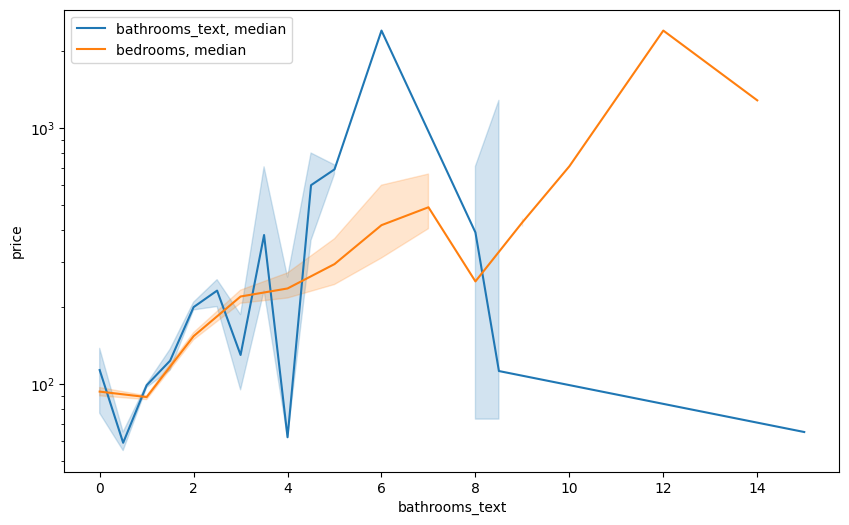

In [241]:
# Aufgabe 1.9 
#from scipy.stats import trim_mean

plt.figure(figsize=(10, 6))

#sns.lineplot(data=listings_1_7, x="review_scores_cleanliness", y="price", estimator=lambda x: trim_mean(x, 0.1), label="trimmed mean")
#sns.lineplot(data=listings_1_7, x="review_scores_cleanliness", y="price", estimator="median", label="review_clean, median")
#sns.lineplot(data=listings_1_7, x="review_scores_rating", y="price", estimator="median", label="review_rating, median")
sns.lineplot(data=listings_1_7, x="bathrooms_text", y="price", estimator="median", label="bathrooms_text, median")
sns.lineplot(data=listings_1_7, x="bedrooms", y="price", estimator="median", label="bedrooms, median")
#sns.lineplot(data=listings_1_7, x="reviews_per_month", y="price", estimator="median", label="reviews_per_month, median")

plt.yscale("log")
plt.legend()
print(listings_1_7.columns)

In [239]:
listings_1_7[["bedrooms", "room_type"]].head(20)

,bedrooms,room_type
0,1.0,Entire home/apt
1,4.0,Entire home/apt
2,0.0,Entire home/apt
3,0.0,Entire home/apt
4,2.0,Entire home/apt
5,2.0,Entire home/apt
6,2.0,Entire home/apt
7,1.0,Entire home/apt
8,2.0,Entire home/apt
9,0.0,Entire home/apt
